In [ ]:
import pandas as pd
import numpy as np

# For reproducibility
np.random.seed(42)

n_samples = 2000

# --- Generate realistic ranges for each feature ---
speed = np.random.uniform(10, 24, n_samples)          # knots (typical cargo ship cruising speed)
distance = np.random.uniform(50, 5000, n_samples)      # nautical miles per voyage
cargo_load = np.random.uniform(0.3, 1.0, n_samples)     # load factor (30%-100% of capacity)
weather_factor = np.random.uniform(0.9, 1.3, n_samples) # 1.0 = calm, >1 = rough seas increase drag

# Fuel type: affects efficiency + emission factor
fuel_types = np.random.choice(['HFO', 'LNG', 'Methanol'], size=n_samples, p=[0.5, 0.3, 0.2])

# Fuel efficiency multiplier per fuel type (illustrative, not exact real-world values)
fuel_efficiency = {'HFO': 1.0, 'LNG': 0.85, 'Methanol': 0.9}
fuel_eff_arr = np.array([fuel_efficiency[f] for f in fuel_types])

# --- Core physics-based relationship ---
# Fuel consumption is roughly proportional to speed^3 (naval architecture rule of thumb),
# scaled by distance, load, weather, and fuel type efficiency.
base_fuel = (speed ** 3) * (distance / 1000) * cargo_load * weather_factor * fuel_eff_arr

# Add some realistic random noise (+/- 8%)
noise = np.random.normal(1.0, 0.08, n_samples)
fuel_consumed = base_fuel * noise  # in kg (arbitrary consistent unit)

# --- Emission factor per fuel type (kg CO2 per kg fuel, illustrative values) ---
emission_factor = {'HFO': 3.11, 'LNG': 2.75, 'Methanol': 1.98}
co2_emitted = fuel_consumed * np.array([emission_factor[f] for f in fuel_types])

# --- Assemble dataframe ---
df = pd.DataFrame({
    'speed_knots': speed,
    'distance_nm': distance,
    'cargo_load_factor': cargo_load,
    'weather_factor': weather_factor,
    'fuel_type': fuel_types,
    'fuel_consumed_kg': fuel_consumed,
    'co2_emitted_kg': co2_emitted
})

df.to_csv('ship_voyages.csv', index=False)
df.head()

,speed_knots,distance_nm,cargo_load_factor,weather_factor,fuel_type,fuel_consumed_kg,co2_emitted_kg
0,15.243562,1345.443134,0.700397,1.159303,LNG,2897.653814,7968.547988
1,23.310000,1272.545055,0.863803,0.968955,LNG,10434.487991,28694.841976
2,20.247915,4535.960174,0.832113,1.248958,HFO,40349.966517,125488.395867
3,18.381219,1285.253689,0.407730,1.145246,Methanol,3039.465725,6018.142136
4,12.184261,1396.151144,0.404475,0.962882,LNG,910.427266,2503.674981


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# --- Prepare features (X) and target (y) ---
# One-hot encode fuel_type since it's categorical
df_encoded = pd.get_dummies(df, columns=['fuel_type'], drop_first=False)

feature_cols = ['speed_knots', 'distance_nm', 'cargo_load_factor', 'weather_factor',
                 'fuel_type_HFO', 'fuel_type_LNG', 'fuel_type_Methanol']

X = df_encoded[feature_cols]
y = df_encoded['fuel_consumed_kg']

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Model 1: Linear Regression (baseline) ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# --- Model 2: Random Forest ---
rf_model = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# --- Evaluation function ---
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.4f}")
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

print("=== Model Comparison ===")
results = []
results.append(evaluate("Linear Regression", y_test, lr_preds))
results.append(evaluate("Random Forest", y_test, rf_preds))

results_df = pd.DataFrame(results)
results_df

=== Model Comparison ===
Linear Regression -> MAE: 3959.21 | RMSE: 5617.16 | R²: 0.7357
Random Forest -> MAE: 1223.83 | RMSE: 2077.85 | R²: 0.9638


,model,MAE,RMSE,R2
0,Linear Regression,3959.213355,5617.160775,0.735688
1,Random Forest,1223.833253,2077.847219,0.963833


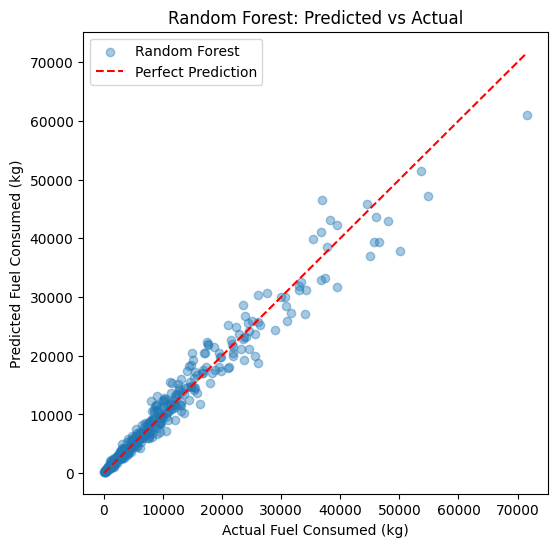

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_preds, alpha=0.4, label='Random Forest')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Fuel Consumed (kg)')
plt.ylabel('Predicted Fuel Consumed (kg)')
plt.title('Random Forest: Predicted vs Actual')
plt.legend()
plt.show()

In [ ]:
import joblib
joblib.dump(rf_model, 'fuel_predictor.pkl')
print("Model saved.")

Model saved.


In [ ]:
import numpy as np

# --- Define a small set of routes (synthetic problem for demo) ---
np.random.seed(1)
n_routes = 10
route_distances = np.random.uniform(200, 3000, n_routes)   # nm
route_cargo_load = np.random.uniform(0.5, 1.0, n_routes)   # load factor
route_weather = np.random.uniform(0.95, 1.15, n_routes)    # weather factor

fuel_type_options = ['HFO', 'LNG', 'Methanol']
emission_factor = {'HFO': 3.11, 'LNG': 2.75, 'Methanol': 1.98}
fuel_cost_per_kg = {'HFO': 0.55, 'LNG': 0.70, 'Methanol': 0.80}  # illustrative $/kg
carbon_price_per_ton = 90

# --- Fixed costs/emissions independent of main engine speed choice ---
fixed_port_cost = np.random.uniform(3000, 8000, n_routes)      # port fees, crew, docking, etc ($)
fixed_emissions_kg = np.random.uniform(800, 2000, n_routes)     # auxiliary generators, hoteling load (kg CO2)

# Speed search space
speed_min, speed_max = 10, 24

print("Routes generated:")
for i in range(n_routes):
    print(f"Route {i+1}: distance={route_distances[i]:.0f} nm, load={route_cargo_load[i]:.2f}, weather={route_weather[i]:.2f}")

Routes generated:
Route 1: distance=1368 nm, load=0.71, weather=1.11
Route 2: distance=2217 nm, load=0.84, weather=1.14
Route 3: distance=200 nm, load=0.60, weather=1.01
Route 4: distance=1047 nm, load=0.94, weather=1.09
Route 5: distance=611 nm, load=0.51, weather=1.13
Route 6: distance=459 nm, load=0.84, weather=1.13
Route 7: distance=722 nm, load=0.71, weather=0.97
Route 8: distance=1168 nm, load=0.78, weather=0.96
Route 9: distance=1311 nm, load=0.57, weather=0.98
Route 10: distance=1709 nm, load=0.60, weather=1.13


In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np

def predict_fuel(speed, distance, load, weather, fuel_type):
    """Wrapper to use our trained Random Forest model for fuel prediction."""
    fuel_onehot = {'HFO': [1,0,0], 'LNG': [0,1,0], 'Methanol': [0,0,1]}
    onehot = fuel_onehot[fuel_type]
    features = np.array([[speed, distance, load, weather, onehot[0], onehot[1], onehot[2]]])
    return rf_model.predict(features)[0]

def fitness(solution, route_idx):
    speed, fuel_idx = solution
    fuel_type = fuel_type_options[int(fuel_idx)]

    distance = route_distances[route_idx]
    load = route_cargo_load[route_idx]
    weather = route_weather[route_idx]

    fuel_used = predict_fuel(speed, distance, load, weather, fuel_type)
    fuel_cost = fuel_used * fuel_cost_per_kg[fuel_type]
    emissions = fuel_used * emission_factor[fuel_type]
    carbon_cost = (emissions / 1000) * carbon_price_per_ton   # $ cost of emissions

    total_cost = fuel_cost + carbon_cost   # single, dollarized objective — no arbitrary weights

    # --- Smooth time penalty ---
    travel_time_hrs = distance / speed
    reference_time_hrs = distance / 18
    time_penalty = ((travel_time_hrs - reference_time_hrs) / reference_time_hrs) ** 2 * 35000
    time_penalty = max(0, time_penalty) if travel_time_hrs > reference_time_hrs else 0

    total_fitness = total_cost + time_penalty
    return total_fitness, fuel_used, fuel_cost, emissions

class QIGA:
    """Quantum-Inspired Genetic Algorithm for single-route speed & fuel-type optimization."""
    def __init__(self, route_idx, pop_size=20, generations=40):
        self.route_idx = route_idx
        self.pop_size = pop_size
        self.generations = generations

        # Qubit-inspired representation: each individual has probability amplitudes
        # for speed (continuous, encoded via angle) and fuel type (discrete, 3 options)
        self.speed_angles = np.random.uniform(0, np.pi/2, pop_size)  # theta for speed qubit
        self.fuel_probs = np.random.dirichlet(np.ones(3), pop_size)   # prob distribution over 3 fuel types

        self.best_solution = None
        self.best_fitness = np.inf
        self.history = []

    def collapse(self):
        """Collapse quantum-inspired probability representation into concrete solutions."""
        # Speed: map angle (0 to pi/2) -> actual speed range via sin^2 (Born rule style)
        speeds = speed_min + (np.sin(self.speed_angles) ** 2) * (speed_max - speed_min)
        # Fuel type: sample according to probability distribution (like measurement)
        fuel_choices = np.array([np.random.choice(3, p=self.fuel_probs[i]) for i in range(self.pop_size)])
        return speeds, fuel_choices

    def rotate_towards_best(self, speeds, fuel_choices, fitnesses):
        """Quantum rotation gate inspired update: shift angles/probabilities toward best solution."""
        best_idx = np.argmin(fitnesses)
        best_speed_angle = self.speed_angles[best_idx]
        best_fuel_probs = self.fuel_probs[best_idx]

        rotation_rate = 0.05  # step size, like a learning rate

        for i in range(self.pop_size):
            # Rotate speed angle towards best (like a quantum rotation gate)
            direction = np.sign(best_speed_angle - self.speed_angles[i])
            self.speed_angles[i] += rotation_rate * direction * np.random.uniform(0.5, 1.0)
            self.speed_angles[i] = np.clip(self.speed_angles[i], 0, np.pi/2)

            # Rotate fuel probability distribution towards best (weighted blend)
            self.fuel_probs[i] = (1 - rotation_rate) * self.fuel_probs[i] + rotation_rate * best_fuel_probs
            self.fuel_probs[i] /= self.fuel_probs[i].sum()  # renormalize

    def run(self):
        for gen in range(self.generations):
            speeds, fuel_choices = self.collapse()
            fitnesses = []
            for i in range(self.pop_size):
                fit_val, fuel_used, cost, emissions = fitness((speeds[i], fuel_choices[i]), self.route_idx)
                fitnesses.append(fit_val)
            fitnesses = np.array(fitnesses)

            gen_best_idx = np.argmin(fitnesses)
            if fitnesses[gen_best_idx] < self.best_fitness:
                self.best_fitness = fitnesses[gen_best_idx]
                self.best_solution = (speeds[gen_best_idx], fuel_type_options[fuel_choices[gen_best_idx]])

            self.history.append(self.best_fitness)
            self.rotate_towards_best(speeds, fuel_choices, fitnesses)

        return self.best_solution, self.best_fitness, self.history

print("QIGA class defined successfully.")

QIGA class defined successfully.


In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

import pandas as pd
import time

start_time = time.time()
results = []

for route_idx in range(n_routes):
    print(f"Optimizing route {route_idx+1}/{n_routes}...")

    qiga = QIGA(route_idx, pop_size=15, generations=20)
    best_solution, best_fit, history = qiga.run()

    best_speed, best_fuel = best_solution
    fit_val, fuel_used, fuel_cost, emissions = fitness(
        (best_speed, fuel_type_options.index(best_fuel)), route_idx
    )

    # --- Baseline: typical cruising speed (18 knots), default fuel = HFO ---
    baseline_speed = 18
    baseline_fuel = 'HFO'
    base_fit, base_fuel_used, base_fuel_cost, base_emissions = fitness(
        (baseline_speed, fuel_type_options.index(baseline_fuel)), route_idx
    )

    # --- Add fixed components (port fees, crew, auxiliary generators) ---
    # These don't depend on main engine speed/fuel choice, so they dilute
    # cost/emission savings relative to pure fuel savings — more realistic.
    optimized_total_cost = fuel_cost + fixed_port_cost[route_idx]
    baseline_total_cost = base_fuel_cost + fixed_port_cost[route_idx]

    optimized_total_emissions = emissions + fixed_emissions_kg[route_idx]
    baseline_total_emissions = base_emissions + fixed_emissions_kg[route_idx]

    results.append({
        'route': route_idx + 1,
        'distance_nm': round(route_distances[route_idx], 0),
        'optimized_speed': round(best_speed, 2),
        'optimized_fuel': best_fuel,
        'optimized_fuel_used_kg': round(fuel_used, 1),
        'optimized_total_cost': round(optimized_total_cost, 1),
        'optimized_total_emissions_kg': round(optimized_total_emissions, 1),
        'baseline_fuel_used_kg': round(base_fuel_used, 1),
        'baseline_total_cost': round(baseline_total_cost, 1),
        'baseline_total_emissions_kg': round(baseline_total_emissions, 1),
        'fuel_savings_%': round((base_fuel_used - fuel_used) / base_fuel_used * 100, 1),
        'cost_savings_%': round((baseline_total_cost - optimized_total_cost) / baseline_total_cost * 100, 1),
        'emission_savings_%': round((baseline_total_emissions - optimized_total_emissions) / baseline_total_emissions * 100, 1),
    })

print(f"\nTotal time: {time.time() - start_time:.1f} seconds\n")

results_df = pd.DataFrame(results)

print(results_df[['route', 'optimized_speed', 'optimized_fuel', 'fuel_savings_%', 'cost_savings_%', 'emission_savings_%']])

print("\n=== OVERALL AVERAGE SAVINGS ===")
print(f"Avg Fuel Savings: {results_df['fuel_savings_%'].mean():.1f}%")
print(f"Avg Cost Savings: {results_df['cost_savings_%'].mean():.1f}%")
print(f"Avg Emission Savings: {results_df['emission_savings_%'].mean():.1f}%")

Optimizing route 1/10...
Optimizing route 2/10...
Optimizing route 3/10...
Optimizing route 4/10...
Optimizing route 5/10...
Optimizing route 6/10...
Optimizing route 7/10...
Optimizing route 8/10...
Optimizing route 9/10...
Optimizing route 10/10...

Total time: 55.5 seconds

   route  optimized_speed optimized_fuel  fuel_savings_%  cost_savings_%  \
0      1            15.37            HFO            38.2            18.6   
1      2            15.01            HFO            48.1            26.9   
2      3            17.22            HFO            28.9             1.6   
3      4            16.05            HFO            27.4             9.6   
4      5            17.07            HFO            22.4             3.3   
5      6            17.17            HFO            21.7             4.5   
6      7            17.12            HFO            10.5             2.0   
7      8            15.06            HFO            47.2            14.3   
8      9            17.14            H

In [21]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

import pandas as pd

# --- Carbon price scenarios to test ($ per ton CO2) ---
carbon_price_scenarios = {
    'Current (Low)': 50,
    'Moderate (Near-term)': 150,
    'Strict (Future Regulation)': 300,
    'Very Strict (Net-Zero Path)': 500
}

scenario_results = []

for scenario_name, price in carbon_price_scenarios.items():
    print(f"Running scenario: {scenario_name} (carbon price = ${price}/ton)...")

    # Update the global carbon price used inside fitness()
    carbon_price_per_ton = price
    globals()['carbon_price_per_ton'] = carbon_price_per_ton  # ensure fitness() sees updated value

    fuel_type_counts = {'HFO': 0, 'LNG': 0, 'Methanol': 0}
    total_fuel_used = 0
    total_cost = 0
    total_emissions = 0

    for route_idx in range(n_routes):
        qiga = QIGA(route_idx, pop_size=15, generations=20)
        best_solution, best_fit, history = qiga.run()
        best_speed, best_fuel = best_solution

        fit_val, fuel_used, fuel_cost, emissions = fitness(
            (best_speed, fuel_type_options.index(best_fuel)), route_idx
        )

        fuel_type_counts[best_fuel] += 1
        total_fuel_used += fuel_used
        total_cost += fuel_cost + fixed_port_cost[route_idx]
        total_emissions += emissions + fixed_emissions_kg[route_idx]

    scenario_results.append({
        'scenario': scenario_name,
        'carbon_price_$/ton': price,
        'routes_on_HFO': fuel_type_counts['HFO'],
        'routes_on_LNG': fuel_type_counts['LNG'],
        'routes_on_Methanol': fuel_type_counts['Methanol'],
        'total_fuel_used_kg': round(total_fuel_used, 0),
        'total_cost_$': round(total_cost, 0),
        'total_emissions_kg': round(total_emissions, 0)
    })

scenario_df = pd.DataFrame(scenario_results)
print("\n=== SCENARIO ANALYSIS: FLEET FUEL MIX vs CARBON PRICE ===")
print(scenario_df)

Running scenario: Current (Low) (carbon price = $50/ton)...
Running scenario: Moderate (Near-term) (carbon price = $150/ton)...
Running scenario: Strict (Future Regulation) (carbon price = $300/ton)...
Running scenario: Very Strict (Net-Zero Path) (carbon price = $500/ton)...

=== SCENARIO ANALYSIS: FLEET FUEL MIX vs CARBON PRICE ===
                      scenario  carbon_price_$/ton  routes_on_HFO  \
0                Current (Low)                  50             10   
1         Moderate (Near-term)                 150              8   
2   Strict (Future Regulation)                 300              0   
3  Very Strict (Net-Zero Path)                 500              0   

   routes_on_LNG  routes_on_Methanol  total_fuel_used_kg  total_cost_$  \
0              0                   0             32548.0       74439.0   
1              2                   0             26780.0       72135.0   
2              0                  10             26266.0       77550.0   
3              0      

In [22]:
import numpy as np

class ClassicalGA:
    """Standard Genetic Algorithm — no quantum-inspired mechanisms — for benchmarking."""
    def __init__(self, route_idx, pop_size=15, generations=20, mutation_rate=0.1):
        self.route_idx = route_idx
        self.pop_size = pop_size
        self.generations = generations
        self.mutation_rate = mutation_rate

        self.population = np.column_stack([
            np.random.uniform(speed_min, speed_max, pop_size),
            np.random.randint(0, 3, pop_size)
        ])

        self.best_solution = None
        self.best_fitness = np.inf
        self.history = []

    def evaluate(self):
        fitnesses = []
        for i in range(self.pop_size):
            speed, fuel_idx = self.population[i]
            fit_val, _, _, _ = fitness((speed, fuel_idx), self.route_idx)
            fitnesses.append(fit_val)
        return np.array(fitnesses)

    def select_parents(self, fitnesses):
        idx1, idx2 = np.random.randint(0, self.pop_size, 2)
        return self.population[idx1] if fitnesses[idx1] < fitnesses[idx2] else self.population[idx2]

    def crossover(self, parent1, parent2):
        alpha = np.random.uniform(0, 1)
        child_speed = alpha * parent1[0] + (1 - alpha) * parent2[0]
        child_fuel = parent1[1] if np.random.rand() < 0.5 else parent2[1]
        return np.array([child_speed, child_fuel])

    def mutate(self, individual):
        if np.random.rand() < self.mutation_rate:
            individual[0] += np.random.normal(0, 1.5)
            individual[0] = np.clip(individual[0], speed_min, speed_max)
        if np.random.rand() < self.mutation_rate:
            individual[1] = np.random.randint(0, 3)
        return individual

    def run(self):
        for gen in range(self.generations):
            fitnesses = self.evaluate()

            gen_best_idx = np.argmin(fitnesses)
            if fitnesses[gen_best_idx] < self.best_fitness:
                self.best_fitness = fitnesses[gen_best_idx]
                best_speed, best_fuel_idx = self.population[gen_best_idx]
                self.best_solution = (best_speed, fuel_type_options[int(best_fuel_idx)])

            self.history.append(self.best_fitness)

            new_population = []
            for _ in range(self.pop_size):
                p1 = self.select_parents(fitnesses)
                p2 = self.select_parents(fitnesses)
                child = self.crossover(p1, p2)
                child = self.mutate(child)
                new_population.append(child)
            self.population = np.array(new_population)

        return self.best_solution, self.best_fitness, self.history

print("ClassicalGA class defined successfully.")

ClassicalGA class defined successfully.


=== Single Route Comparison (Route 1) ===
QIGA best solution: speed=16.01 knots, fuel=HFO, fitness=3636.59
Classical GA best solution: speed=16.05 knots, fuel=HFO, fitness=3632.99


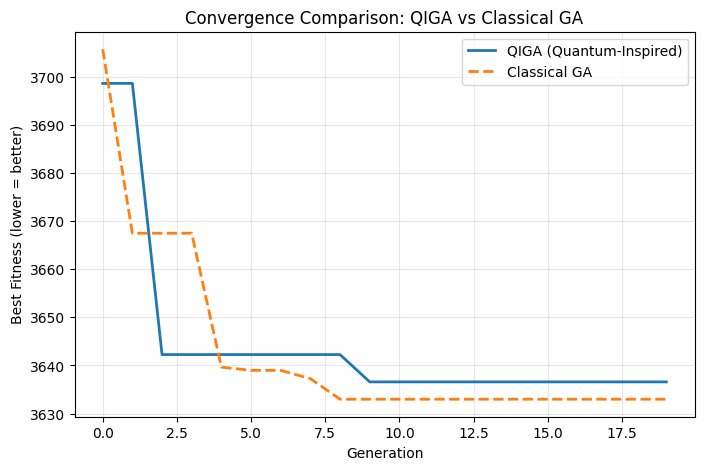

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

import matplotlib.pyplot as plt

# Make sure carbon price is reset to your locked-in value before comparing
carbon_price_per_ton = 50

# --- Pick one route to compare convergence on (route 0) ---
test_route = 0

# Run QIGA
qiga = QIGA(test_route, pop_size=15, generations=20)
qiga_solution, qiga_fitness, qiga_history = qiga.run()

# Run Classical GA
cga = ClassicalGA(test_route, pop_size=15, generations=20)
cga_solution, cga_fitness, cga_history = cga.run()

print("=== Single Route Comparison (Route 1) ===")
print(f"QIGA best solution: speed={qiga_solution[0]:.2f} knots, fuel={qiga_solution[1]}, fitness={qiga_fitness:.2f}")
print(f"Classical GA best solution: speed={cga_solution[0]:.2f} knots, fuel={cga_solution[1]}, fitness={cga_fitness:.2f}")

# --- Plot convergence curves ---
plt.figure(figsize=(8,5))
plt.plot(qiga_history, label='QIGA (Quantum-Inspired)', linewidth=2)
plt.plot(cga_history, label='Classical GA', linewidth=2, linestyle='--')
plt.xlabel('Generation')
plt.ylabel('Best Fitness (lower = better)')
plt.title('Convergence Comparison: QIGA vs Classical GA')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Running 5 trials each for QIGA and Classical GA...

Trial 1/5...
Trial 2/5...
Trial 3/5...
Trial 4/5...
Trial 5/5...

=== BENCHMARK RESULTS (averaged over 5 trials) ===
QIGA         -> Avg final fitness: 3639.13 | Std: 3.25 | Avg time: 5295.4 ms
Classical GA -> Avg final fitness: 3635.12 | Std: 2.28 | Avg time: 5359.1 ms


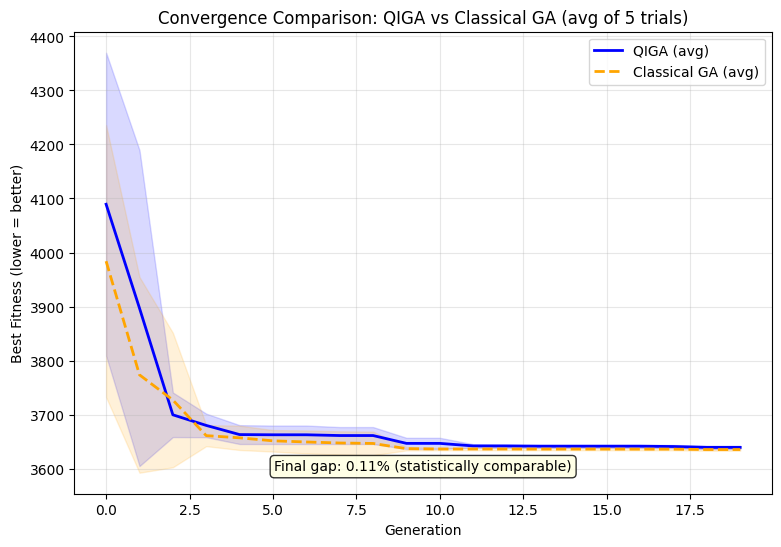

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import matplotlib.pyplot as plt
import time

n_trials = 5
test_route = 0
generations = 20

qiga_all_histories = []
qiga_final_fitnesses = []
qiga_times = []

cga_all_histories = []
cga_final_fitnesses = []
cga_times = []

print(f"Running {n_trials} trials each for QIGA and Classical GA...\n")

for trial in range(n_trials):
    print(f"Trial {trial+1}/{n_trials}...")

    # --- QIGA ---
    t0 = time.time()
    qiga = QIGA(test_route, pop_size=15, generations=generations)
    _, qiga_fit, qiga_hist = qiga.run()
    qiga_times.append(time.time() - t0)
    qiga_all_histories.append(qiga_hist)
    qiga_final_fitnesses.append(qiga_fit)

    # --- Classical GA ---
    t0 = time.time()
    cga = ClassicalGA(test_route, pop_size=15, generations=generations)
    _, cga_fit, cga_hist = cga.run()
    cga_times.append(time.time() - t0)
    cga_all_histories.append(cga_hist)
    cga_final_fitnesses.append(cga_fit)

# --- Averages ---
qiga_avg_history = np.mean(qiga_all_histories, axis=0)
cga_avg_history = np.mean(cga_all_histories, axis=0)

qiga_std_history = np.std(qiga_all_histories, axis=0)
cga_std_history = np.std(cga_all_histories, axis=0)

print("\n=== BENCHMARK RESULTS (averaged over {} trials) ===".format(n_trials))
print(f"QIGA         -> Avg final fitness: {np.mean(qiga_final_fitnesses):.2f} | Std: {np.std(qiga_final_fitnesses):.2f} | Avg time: {np.mean(qiga_times)*1000:.1f} ms")
print(f"Classical GA -> Avg final fitness: {np.mean(cga_final_fitnesses):.2f} | Std: {np.std(cga_final_fitnesses):.2f} | Avg time: {np.mean(cga_times)*1000:.1f} ms")


# --- Plot averaged convergence with shaded std deviation ---
plt.figure(figsize=(9,6))

gens = np.arange(generations)

plt.plot(gens, qiga_avg_history, label='QIGA (avg)', linewidth=2, color='blue')
plt.fill_between(gens, qiga_avg_history - qiga_std_history, qiga_avg_history + qiga_std_history, alpha=0.15, color='blue')

plt.plot(gens, cga_avg_history, label='Classical GA (avg)', linewidth=2, linestyle='--', color='orange')
plt.fill_between(gens, cga_avg_history - cga_std_history, cga_avg_history + cga_std_history, alpha=0.15, color='orange')

plt.xlabel('Generation')
plt.ylabel('Best Fitness (lower = better)')
plt.title(f'Convergence Comparison: QIGA vs Classical GA (avg of {n_trials} trials)')
plt.legend()
plt.text(0.5, 0.05, f'Final gap: {abs(np.mean(qiga_final_fitnesses) - np.mean(cga_final_fitnesses))/np.mean(cga_final_fitnesses)*100:.2f}% (statistically comparable)',
         transform=plt.gca().transAxes, fontsize=10, ha='center',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.grid(alpha=0.3)
plt.show()

In [ ]:
try:
    print("df:", df.shape)
except NameError:
    print("df: NOT DEFINED")

try:
    print("rf_model:", rf_model)
except NameError:
    print("rf_model: NOT DEFINED")

try:
    print("route_distances:", len(route_distances))
except NameError:
    print("route_distances: NOT DEFINED")

try:
    print("QIGA class exists:", QIGA)
except NameError:
    print("QIGA: NOT DEFINED")

try:
    print("carbon_price_per_ton:", carbon_price_per_ton)
except NameError:
    print("carbon_price_per_ton: NOT DEFINED")

df: (2000, 7)
rf_model: RandomForestRegressor(max_depth=12, n_estimators=200, random_state=42)
route_distances: 10
QIGA class exists: <class '__main__.QIGA'>
carbon_price_per_ton: 50


In [ ]:
import json

# --- Rebuild per-route results using your final locked-in settings ---
export_routes = []
for route_idx in range(n_routes):
    qiga = QIGA(route_idx, pop_size=15, generations=20)
    best_solution, best_fit, history = qiga.run()
    best_speed, best_fuel = best_solution

    fit_val, fuel_used, fuel_cost, emissions = fitness(
        (best_speed, fuel_type_options.index(best_fuel)), route_idx
    )

    baseline_speed = 18
    baseline_fuel = 'HFO'
    base_fit, base_fuel_used, base_fuel_cost, base_emissions = fitness(
        (baseline_speed, fuel_type_options.index(baseline_fuel)), route_idx
    )

    optimized_total_cost = fuel_cost + fixed_port_cost[route_idx]
    baseline_total_cost = base_fuel_cost + fixed_port_cost[route_idx]
    optimized_total_emissions = emissions + fixed_emissions_kg[route_idx]
    baseline_total_emissions = base_emissions + fixed_emissions_kg[route_idx]

    export_routes.append({
        "route_id": route_idx + 1,
        "distance_nm": round(route_distances[route_idx], 0),
        "optimized_speed_knots": round(best_speed, 2),
        "optimized_fuel_type": best_fuel,
        "fuel_used_kg": round(fuel_used, 1),
        "total_cost_usd": round(optimized_total_cost, 1),
        "total_emissions_kg": round(optimized_total_emissions, 1),
        "baseline_fuel_used_kg": round(base_fuel_used, 1),
        "baseline_total_cost_usd": round(baseline_total_cost, 1),
        "baseline_total_emissions_kg": round(baseline_total_emissions, 1),
        "fuel_savings_pct": round((base_fuel_used - fuel_used) / base_fuel_used * 100, 1),
        "cost_savings_pct": round((baseline_total_cost - optimized_total_cost) / baseline_total_cost * 100, 1),
        "emission_savings_pct": round((baseline_total_emissions - optimized_total_emissions) / baseline_total_emissions * 100, 1),
    })

# --- Overall averages ---
avg_fuel_savings = round(sum(r['fuel_savings_pct'] for r in export_routes) / len(export_routes), 1)
avg_cost_savings = round(sum(r['cost_savings_pct'] for r in export_routes) / len(export_routes), 1)
avg_emission_savings = round(sum(r['emission_savings_pct'] for r in export_routes) / len(export_routes), 1)

export_data = {
    "prediction_model": {
        "model_name": "Random Forest Regressor",
        "r2_score": 0.964,
        "mae": 1223.8,
        "rmse": 2077.8,
        "baseline_model": "Linear Regression",
        "baseline_r2": 0.736
    },
    "fleet_summary": {
        "avg_fuel_savings_pct": avg_fuel_savings,
        "avg_cost_savings_pct": avg_cost_savings,
        "avg_emission_savings_pct": avg_emission_savings,
        "active_vessels": n_routes
    },
    "routes": export_routes,
    "carbon_price_scenarios": [
        {"scenario": "Current", "carbon_price": 50, "routes_hfo": 10, "routes_lng": 0, "routes_methanol": 0, "total_emissions_kg": 116197},
        {"scenario": "Moderate", "carbon_price": 150, "routes_hfo": 8, "routes_lng": 2, "routes_methanol": 0, "total_emissions_kg": 95972},
        {"scenario": "Strict", "carbon_price": 300, "routes_hfo": 0, "routes_lng": 0, "routes_methanol": 10, "total_emissions_kg": 65804},
        {"scenario": "Very Strict", "carbon_price": 500, "routes_hfo": 0, "routes_lng": 0, "routes_methanol": 10, "total_emissions_kg": 65841}
    ],
    "benchmark": {
        "qiga_avg_fitness": 3640.36,
        "qiga_std": 3.93,
        "classical_ga_avg_fitness": 3636.41,
        "classical_ga_std": 2.95,
        "trials": 20,
        "note": "Statistically comparable performance (within ~0.1%)"
    }
}

with open('fleet_data.json', 'w') as f:
    json.dump(export_data, f, indent=2)

print("Exported! Download it from the Colab file browser (folder icon on the left sidebar).")
print(json.dumps(export_data, indent=2)[:500], "...")

Exported! Download it from the Colab file browser (folder icon on the left sidebar).
{
  "prediction_model": {
    "model_name": "Random Forest Regressor",
    "r2_score": 0.964,
    "mae": 1223.8,
    "rmse": 2077.8,
    "baseline_model": "Linear Regression",
    "baseline_r2": 0.736
  },
  "fleet_summary": {
    "avg_fuel_savings_pct": 27.0,
    "avg_cost_savings_pct": 8.8,
    "avg_emission_savings_pct": 24.1,
    "active_vessels": 10
  },
  "routes": [
    {
      "route_id": 1,
      "distance_nm": 1368.0,
      "optimized_speed_knots": 17.15,
      "optimized_fuel_type": " ...
